# Build `gxp_samples.csv`

This notebook has two phases:

1. Exploratory filtering and AHBA-GTEx alignment on a subsetted gene list.
2. Formal `gxp_samples.csv` creation with the same GTEx filtering arguments passed directly into `build_gxp_samples(...)`.


In [6]:
from pathlib import Path

import pandas as pd

from src.samples import build_gxp_samples, compute_gtex_ahba_overlap_report, validate_gxp_samples
from src.samples.gtex import list_brain_gct_files
from src.samples.legacy_alignment import (
    aggregate_ahba_to_gtex_tpm,
    evaluate_ahba_combination_grid,
    evaluate_gtex_tpm_df,
    load_gtex_median_tpm_df,
    subset_tissue_gene_df,
)


In [7]:
import importlib

import src.samples as samples
import src.samples.build as samples_build
import src.samples.gtex as samples_gtex
import src.samples.legacy_alignment as samples_legacy

importlib.reload(samples_gtex)
importlib.reload(samples_build)
importlib.reload(samples_legacy)
importlib.reload(samples)

from pathlib import Path

import pandas as pd

from src.samples import build_gxp_samples, compute_gtex_ahba_overlap_report, validate_gxp_samples
from src.samples.gtex import list_brain_gct_files
from src.samples.legacy_alignment import (
    aggregate_ahba_to_gtex_tpm,
    evaluate_ahba_combination_grid,
    evaluate_gtex_tpm_df,
    load_gtex_median_tpm_df,
    subset_tissue_gene_df,
)


## Setup


In [8]:
GTEX_ROOT = Path('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11')
GTEX_MEDIAN_TPM = GTEX_ROOT / 'brain_RNA-seq' / 'tpm' / 'GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_median_tpm.gct'
GTEX_SAMPLE_ATTRIBUTES = Path('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/metadata/annotations_v8_GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')
GTEX_SUBJECT_PHENOTYPES = Path('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/metadata/annotations_v8_GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt')

AHBA_ROOT = Path('/scratch/asr655/neuroinformatics/GeneEx2Conn_data/AHBA')
AHBA_BA_PATH = AHBA_ROOT / 'BA'
AHBA_S156_PATH = AHBA_ROOT / 'S156'
ATLAS_ROOT = Path('/scratch/asr655/neuroinformatics/GeneEx2Conn_data/atlas_info')
ATLAS_INFO_DIR = Path('data/metadata/atlas_info')

BUILD_GENE_LIST = 'allgenes_stable_r0.2'
BUILD_OUTPUT = Path('data/raw/gxp_samples_test.csv')

GTEX_RIN_THRESHOLD = 6.0
GTEX_TPM_THRESHOLD = 0.1
GTEX_READS_THRESHOLD = 6.0
GTEX_MIN_FRACTION = 0.2

GENE_LISTS = {
    "allgenes_stable_r-1": Path("data/metadata/gene_lists/allgenes_stability_dk/allgenes_stable_r-1.csv"),
    "allgenes_stable_r0.2": Path("data/metadata/gene_lists/allgenes_stability_dk/allgenes_stable_r0.2.csv"),
    "allgenes_stable_r0.4": Path("data/metadata/gene_lists/allgenes_stability_dk/allgenes_stable_r0.4.csv"),
    "allgenes_stable_r0.6": Path("data/metadata/gene_lists/allgenes_stability_dk/allgenes_stable_r0.6.csv"),
    "allgenes_stable_r0.8": Path("data/metadata/gene_lists/allgenes_stability_dk/allgenes_stable_r0.8.csv"),
    "ahba_100hvg": Path("data/metadata/gene_lists/ahba_100hvg.txt"),
    "richiardi2015": Path("data/metadata/gene_lists/richiardi2015.txt"),
}

EXPLORATION_GENE_LIST = 'richiardi2015'
BUILD_GENE_LIST = 'allgenes_stable_r0.2'
BUILD_OUTPUT = Path('data/raw/gxp_samples.csv')


In [9]:
GTEX_ROOT = Path('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11')
list_brain_gct_files(GTEX_ROOT, expression_kind='tpm')


[PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_amygdala.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_anterior_cingulate_cortex_ba24.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_caudate_basal_ganglia.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_cerebellar_hemisphere.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_cerebellum.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/gene_tpm_v11_brain_cortex.gct'),
 PosixPath('/scratch/asr655/neuroinformatics/Seq2GeneEx/neuroVformer/data/GTEx/GTEx_v11/brain_RNA-seq/tpm/

## Part 1. Exploratory Filtering and Alignment

Use a subsetted gene list to inspect GTEx filtering, GTEx-AHBA overlap, and tissue-level AHBA alignment before building `gxp_samples.csv`.


In [10]:
exploration_overlap_info = compute_gtex_ahba_overlap_report(
    gtex_root=GTEX_ROOT,
    sample_attributes_path=GTEX_SAMPLE_ATTRIBUTES,
    ahba_root=AHBA_ROOT,
    ahba_processing='raw',
    ahba_parcellation='S156',
    rin_threshold=GTEX_RIN_THRESHOLD,
    tpm_threshold=GTEX_TPM_THRESHOLD,
    reads_threshold=GTEX_READS_THRESHOLD,
    min_fraction=GTEX_MIN_FRACTION,
    gene_id_style='symbol',
    gene_panel=GENE_LISTS[EXPLORATION_GENE_LIST],
)
EXPLORATION_FILTERED_GENE_LIST = exploration_overlap_info["filtered_genes"]
exploration_overlap_info["report_df"]


,group,step,size
0,gtex,total_gtex_genes_in_tpm,74628
1,gtex,retained_brain_samples_after_rin,2541
2,gtex,genes_passing_tpm_threshold,34995
3,gtex,genes_passing_reads_threshold,30367
4,gtex,gtex_genes_passing_both_thresholds,29080
5,ahba,ahba_genes_available_in_chosen_preprocessing,15633
6,overlap,final_gtex_ahba_overlap_size,14108
7,overlap_loss,ahba_not_in_gtex_tpm_universe,922
8,overlap_loss,ahba_fail_tpm_only_after_rin,63
9,overlap_loss,ahba_fail_reads_only_after_rin,96


## Part 1A. Alignment Grid on the Exploratory Gene List


In [11]:
true_median_tpm_df = load_gtex_median_tpm_df(
    GTEX_MEDIAN_TPM,
    gene_id_style='symbol',
    genes=EXPLORATION_FILTERED_GENE_LIST,
)
true_median_tpm_df.shape


(12, 103)

In [12]:
grid = evaluate_ahba_combination_grid(
    true_median_tpm_df,
    ahba_ba_path=AHBA_BA_PATH,
    ahba_ba_atlas_map=ATLAS_ROOT / 'AtlasMaps' / 'MaptoBA.csv',
    ahba_s156_path=AHBA_S156_PATH,
    ahba_s156_atlas_map=ATLAS_ROOT / 'AtlasMaps' / 'MaptoS156.csv',
)
grid.head(12)

,processing_style,subject_aggregation_style,tissue_aggregation_style,log1p,mirror_interpolate,n_common_tissues,n_overlap_genes,mean_gene_r,mean_tissue_r,rsa_pearson,rsa_spearman,mean,rank
0,raw,mean,mean,False,False,12,103,0.534483,0.655168,0.393698,0.372805,0.489039,1
1,raw,mean,median,False,False,12,103,0.537717,0.655696,0.391555,0.362996,0.486991,2
2,raw,mean,median,False,True,12,103,0.550790,0.657859,0.371830,0.322082,0.475640,3
3,raw,median,mean,False,False,12,103,0.535141,0.656858,0.366855,0.340730,0.474896,4
4,raw,median,median,False,False,12,103,0.536066,0.656619,0.373263,0.333480,0.474857,5
5,raw,mean,mean,False,True,12,103,0.553957,0.657717,0.358995,0.320574,0.472811,6
6,raw,mean,mean,True,False,12,103,0.531339,0.633359,0.313617,0.372805,0.462780,7
7,raw,mean,median,True,False,12,103,0.534022,0.632843,0.315958,0.362996,0.461455,8
8,raw,median,median,False,True,12,103,0.537682,0.657673,0.336290,0.297772,0.457354,9
9,raw,median,mean,False,True,12,103,0.546085,0.659290,0.325476,0.297417,0.457067,10


In [13]:
grid

,processing_style,subject_aggregation_style,tissue_aggregation_style,log1p,mirror_interpolate,n_common_tissues,n_overlap_genes,mean_gene_r,mean_tissue_r,rsa_pearson,rsa_spearman,mean,rank
0,raw,mean,mean,False,False,12,103,0.534483,0.655168,0.393698,0.372805,0.489039,1
1,raw,mean,median,False,False,12,103,0.537717,0.655696,0.391555,0.362996,0.486991,2
2,raw,mean,median,False,True,12,103,0.550790,0.657859,0.371830,0.322082,0.475640,3
3,raw,median,mean,False,False,12,103,0.535141,0.656858,0.366855,0.340730,0.474896,4
4,raw,median,median,False,False,12,103,0.536066,0.656619,0.373263,0.333480,0.474857,5
5,raw,mean,mean,False,True,12,103,0.553957,0.657717,0.358995,0.320574,0.472811,6
6,raw,mean,mean,True,False,12,103,0.531339,0.633359,0.313617,0.372805,0.462780,7
7,raw,mean,median,True,False,12,103,0.534022,0.632843,0.315958,0.362996,0.461455,8
8,raw,median,median,False,True,12,103,0.537682,0.657673,0.336290,0.297772,0.457354,9
9,raw,median,mean,False,True,12,103,0.546085,0.659290,0.325476,0.297417,0.457067,10


## Part 1B. Visualize One Exploratory Strategy


In [14]:
SELECTED_RANK = 1
selected = grid.loc[grid['rank'].eq(SELECTED_RANK)].iloc[0]
selected

processing_style                  raw
subject_aggregation_style        mean
tissue_aggregation_style         mean
log1p                           False
mirror_interpolate              False
n_common_tissues                   12
n_overlap_genes                   103
mean_gene_r                  0.534483
mean_tissue_r                0.655168
rsa_pearson                  0.393698
rsa_spearman                 0.372805
mean                         0.489039
rank                                1
Name: 0, dtype: object

{'n_common_tissues': 12,
 'n_overlap_genes': 103,
 'mean_gene_r': 0.5344834359141107,
 'mean_tissue_r': 0.6551680464726762,
 'mean_gene_r2': 0.38886945410615975,
 'mean_tissue_r2': 0.4347535241822152,
 'std_gene_r': 0.3513436010472518,
 'std_tissue_r': 0.07421829332039542,
 'std_gene_r2': 0.32211145193608853,
 'std_tissue_r2': 0.09113533545565024,
 'rsa_pearson': 0.3936981247558814,
 'rsa_spearman': 0.3728051169698403}

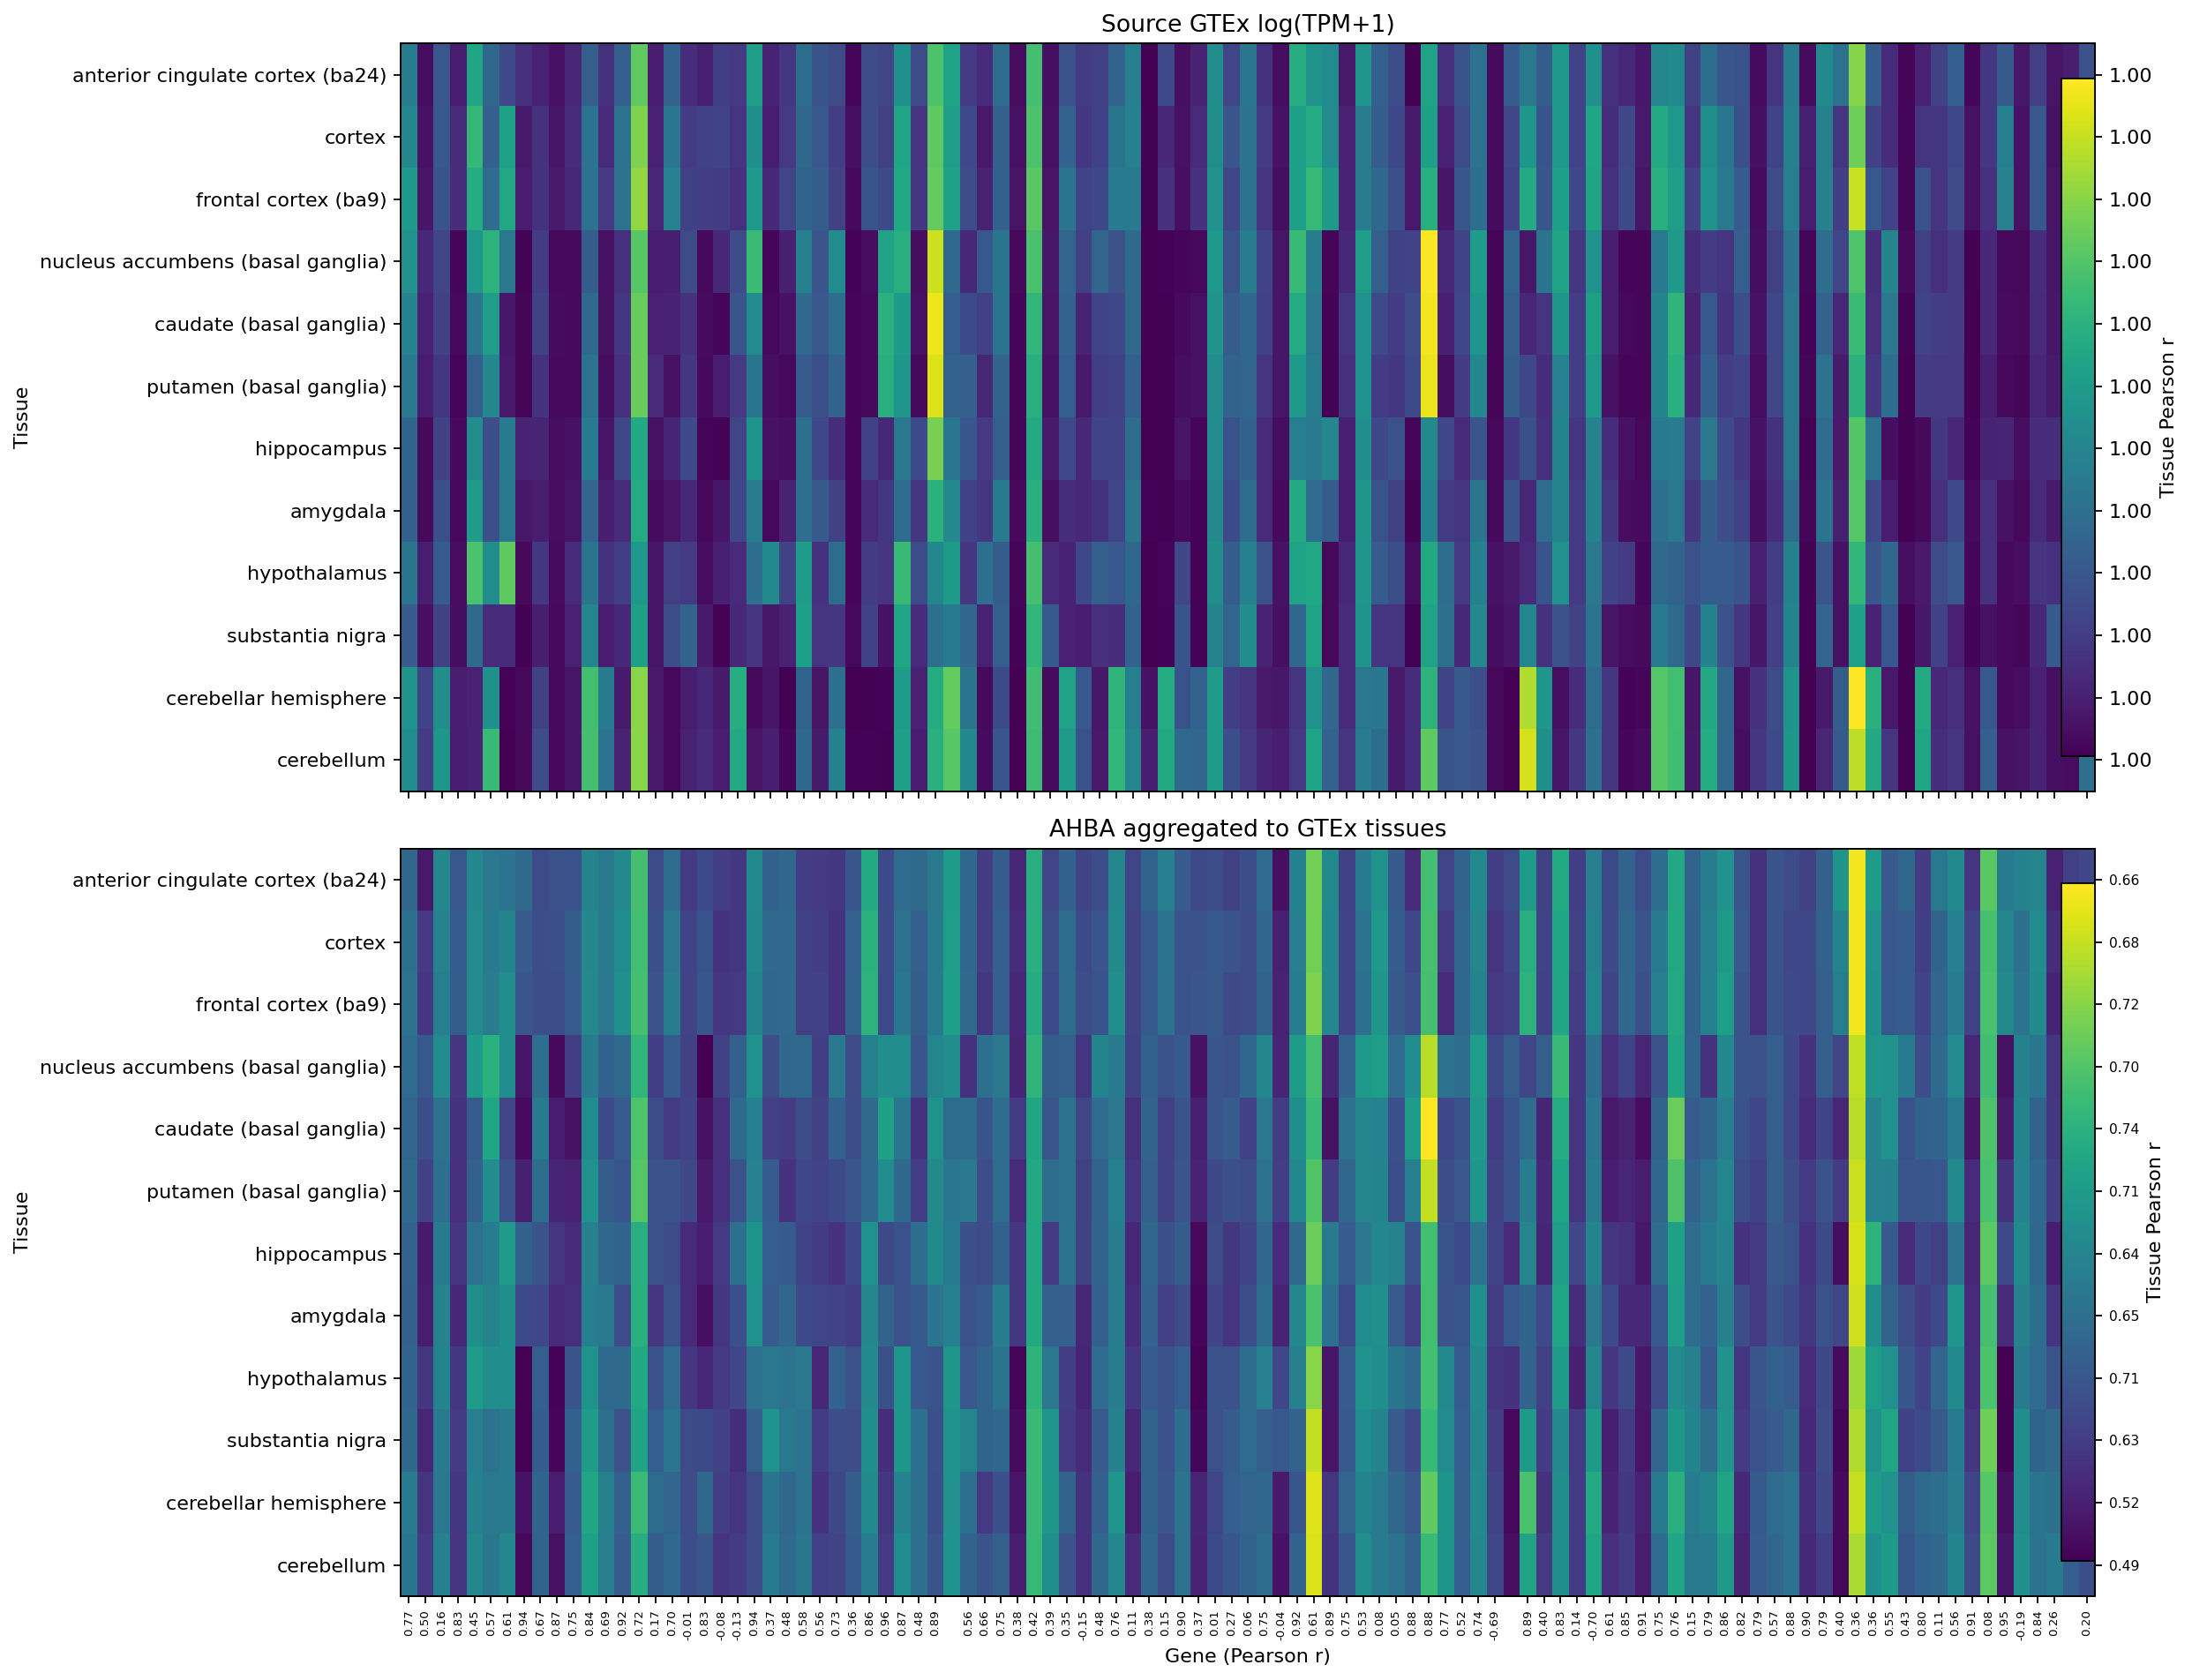

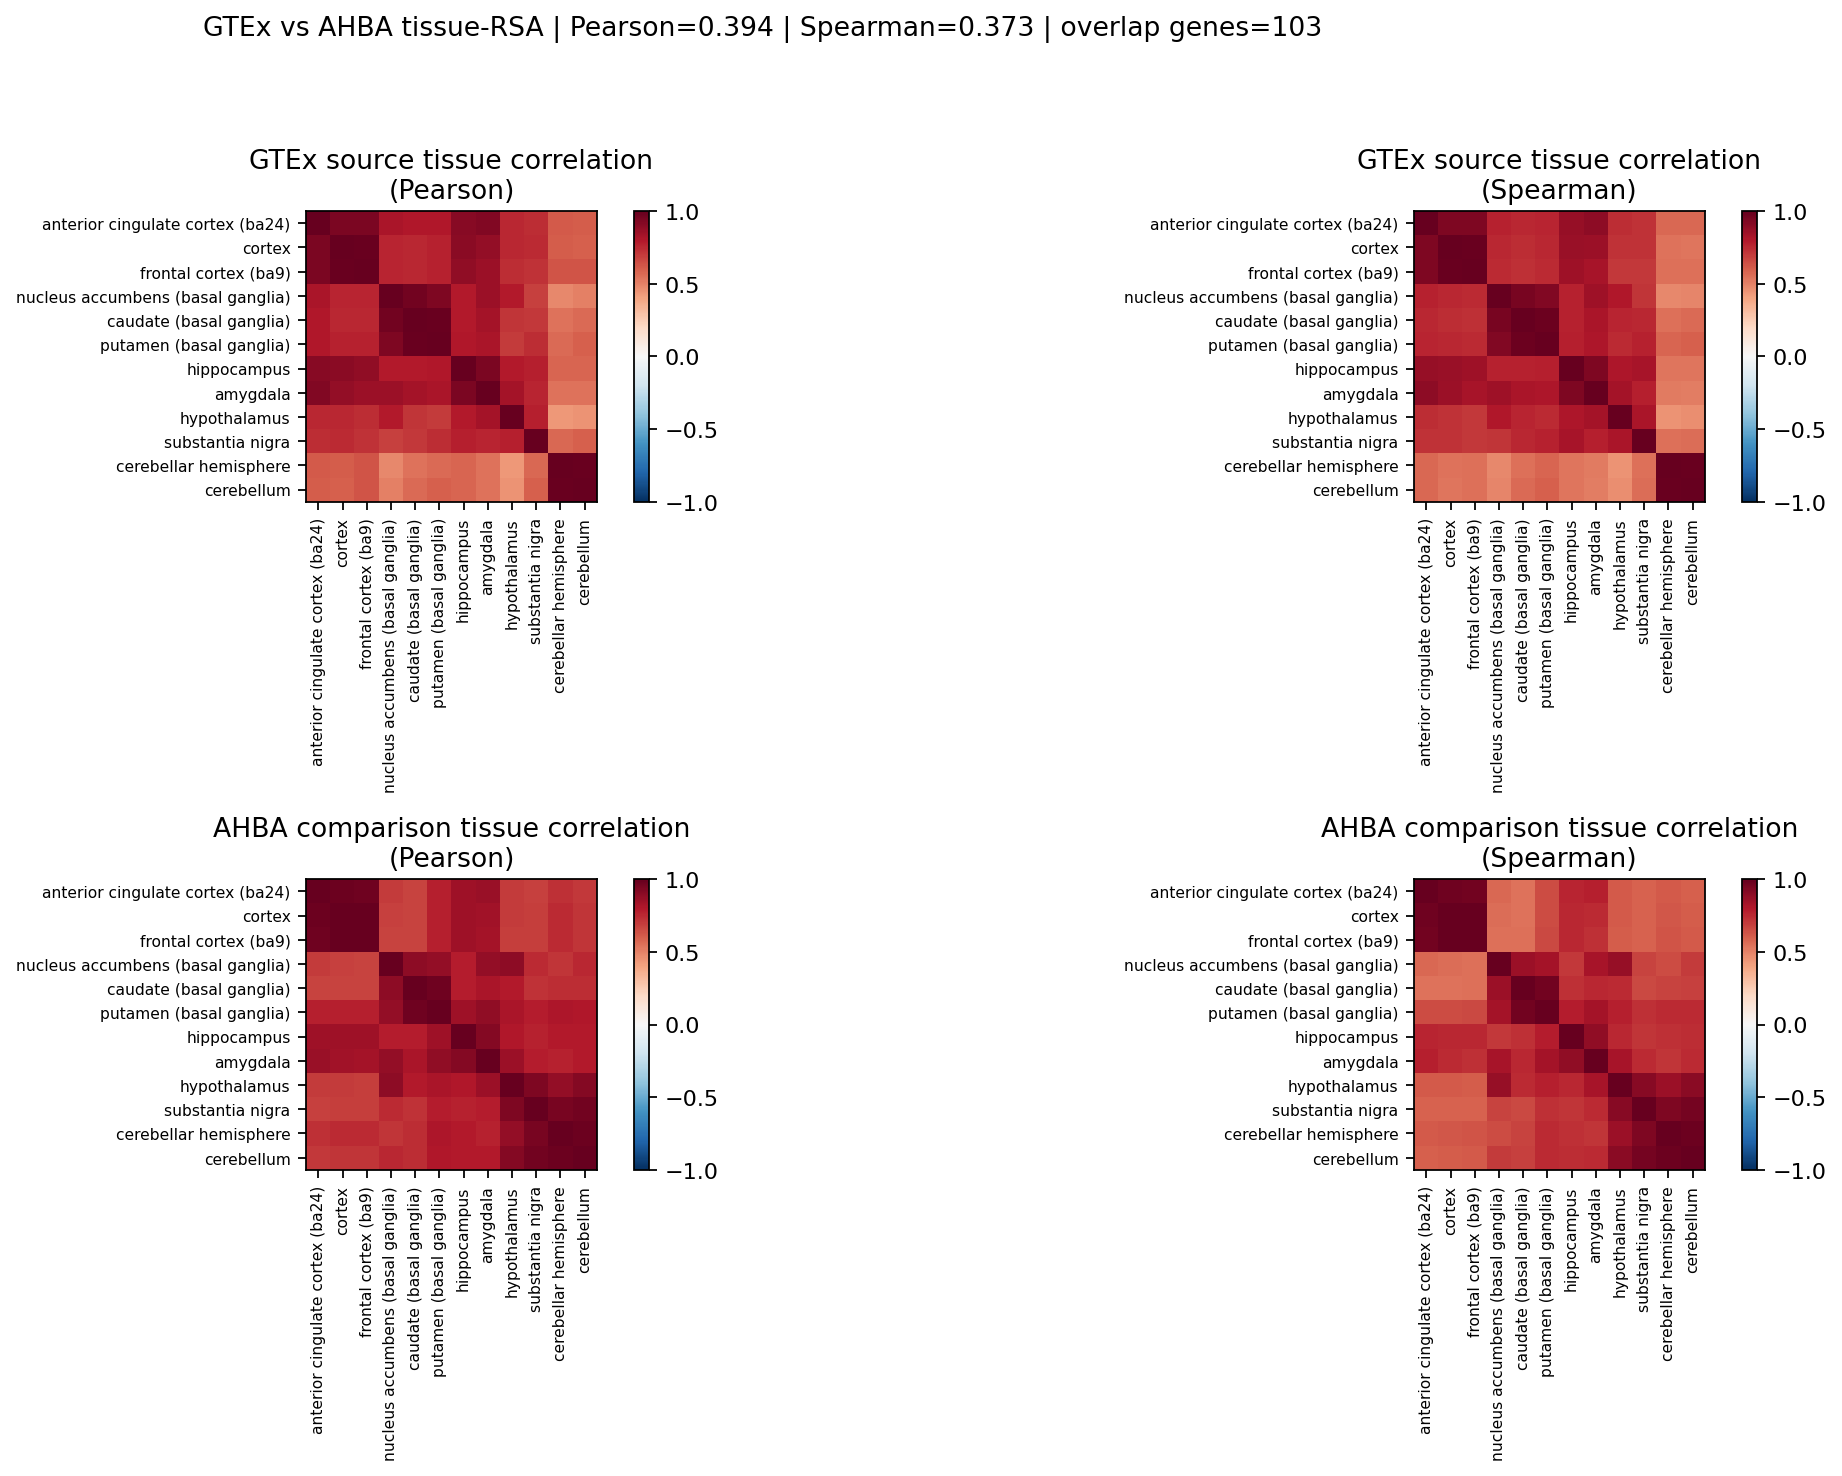

In [15]:
selected_ahba_tissue_df = aggregate_ahba_to_gtex_tpm(
    true_median_tpm_df,
    processing_style=selected.processing_style,
    subject_aggregation_style=selected.subject_aggregation_style,
    tissue_aggregation_style=selected.tissue_aggregation_style,
    log1p=bool(selected.log1p),
    mirror_interpolate=bool(selected.mirror_interpolate),
    ahba_ba_path=AHBA_BA_PATH,
    ahba_ba_atlas_map=ATLAS_ROOT / 'AtlasMaps' / 'MaptoBA.csv',
    ahba_s156_path=AHBA_S156_PATH,
    ahba_s156_atlas_map=ATLAS_ROOT / 'AtlasMaps' / 'MaptoS156.csv',
)

selected_metrics = evaluate_gtex_tpm_df(
    true_median_tpm_df,
    selected_ahba_tissue_df,
    show_metric='r',
    silence_plotting=False,
)
{k: v for k, v in selected_metrics.items() if k != 'figures'}

## Part 2. Formal `gxp_samples.csv` Creation

Run the builder with the GTEx filtering arguments passed directly into `build_gxp_samples(...)`.


In [22]:
import importlib

import src.samples as samples
import src.samples.build as samples_build
import src.samples.gtex as samples_gtex
import src.samples.legacy_alignment as samples_legacy

importlib.reload(samples_gtex)
importlib.reload(samples_build)
importlib.reload(samples_legacy)
importlib.reload(samples)

from pathlib import Path

import pandas as pd

from src.samples import (
    build_gxp_samples,
    compute_gtex_ahba_overlap_report,
    validate_gxp_samples,
)
from src.samples.gtex import list_brain_gct_files
from src.samples.legacy_alignment import (
    aggregate_ahba_to_gtex_tpm,
    evaluate_ahba_combination_grid,
    evaluate_gtex_tpm_df,
    load_gtex_median_tpm_df,
    subset_tissue_gene_df,
)


In [23]:
BUILD_GENE_LIST = 'allgenes_stable_r0.2'
BUILD_OUTPUT = Path('data/raw/gxp_samples_test.csv')

GTEX_RIN_THRESHOLD = 6.0
GTEX_TPM_THRESHOLD = 0.1
GTEX_READS_THRESHOLD = 6.0
GTEX_MIN_FRACTION = 0.2

In [24]:
df, build_overlap_info = build_gxp_samples(
    gtex_root=GTEX_ROOT,
    ahba_root=AHBA_ROOT,
    atlas_info_dir=ATLAS_INFO_DIR,
    gene_panel=GENE_LISTS[BUILD_GENE_LIST],
    gtex_sample_attributes_path=GTEX_SAMPLE_ATTRIBUTES,
    gtex_rin_threshold=GTEX_RIN_THRESHOLD,
    gtex_tpm_threshold=GTEX_TPM_THRESHOLD,
    gtex_reads_threshold=GTEX_READS_THRESHOLD,
    gtex_min_fraction=GTEX_MIN_FRACTION,
    output=BUILD_OUTPUT,
    expression_kind='tpm',
    gtex_transform='log1p',
    gene_id_style='symbol',
    parcellation='S156',
    ahba_processing='raw',
    return_overlap_info=True,
)
build_overlap_info["report_df"]


,group,step,size
0,gtex,total_gtex_genes_in_tpm,74628
1,gtex,retained_brain_samples_after_rin,2541
2,gtex,genes_passing_tpm_threshold,34995
3,gtex,genes_passing_reads_threshold,30367
4,gtex,gtex_genes_passing_both_thresholds,29080
5,ahba,ahba_genes_available_in_chosen_preprocessing,15633
6,overlap,final_gtex_ahba_overlap_size,14108
7,overlap_loss,ahba_not_in_gtex_tpm_universe,922
8,overlap_loss,ahba_fail_tpm_only_after_rin,63
9,overlap_loss,ahba_fail_reads_only_after_rin,96


In [ ]:
validate_gxp_samples(df)
df.shape
